<a href="https://colab.research.google.com/github/DxubleBTW/averylee-money-market-funds-analysis/blob/main/AveryLeeFinanceNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/DxubleBTW/averylee-money-market-funds-analysis/refs/heads/main/mmf-2026-04.csv"

df = pd.read_csv(url)

df.head()

,ReportMonth,registrant_cik,registrant,series_name,series_id,series_category,class_name,class_id,investment_advisor,class_ticker_symbol,sub_advisor
0,2026-04-30,742212,"NORTHWESTERN MUTUAL SERIES FUND, INC.",GOVERNMENT MONEY MARKET PORTFOLIO,S000000048,Government,Government Money Market Portfolio,C000000083,"Mason Street Advisors, LLC",NaN,"BlackRock Advisors, LLC"
1,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Institutional Shares,C000000251,"BNY Mellon Investment Adviser, Inc.",DTRXX,NaN
2,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Investor Shares,C000000252,"BNY Mellon Investment Adviser, Inc.",DTVXX,NaN
3,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Administrative Shares,C000000253,"BNY Mellon Investment Adviser, Inc.",DTAXX,NaN
4,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Participant Shares,C000000254,"BNY Mellon Investment Adviser, Inc.",DTPXX,NaN


# Money Market Funds Analysis
### Columbia Data Science Research Program
By: Avery Lee

## Checkpoint 1: Data Cleaning

This notebook explores the April 2026 SEC Money Market Fund dataset. The goal of this notebook is to clean the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1206
Columns: 11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1206 entries, 0 to 1205
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ReportMonth          1206 non-null   object
 1   registrant_cik       1206 non-null   int64 
 2   registrant           1206 non-null   object
 3   series_name          1206 non-null   object
 4   series_id            1206 non-null   object
 5   series_category      1206 non-null   object
 6   class_name           1206 non-null   object
 7   class_id             1206 non-null   object
 8   investment_advisor   1206 non-null   object
 9   class_ticker_symbol  996 non-null    object
 10  sub_advisor          394 non-null    object
dtypes: int64(1), object(10)
memory usage: 103.8+ KB


In [ ]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_")
)

df.columns

Index(['reportmonth', 'registrant_cik', 'registrant', 'series_name',
       'series_id', 'series_category', 'class_name', 'class_id',
       'investment_advisor', 'class_ticker_symbol', 'sub_advisor'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
reportmonth,0
registrant_cik,0
registrant,0
series_name,0
series_id,0
series_category,0
class_name,0
class_id,0
investment_advisor,0
class_ticker_symbol,210


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
print("Unique Registrants:", df["registrant"].nunique())

print("Unique Fund Series:", df["series_id"].nunique())

print("Unique Share Classes:", df["class_id"].nunique())

print("Fund Categories:")
print(df["series_category"].value_counts())

Unique Registrants: 187
Unique Fund Series: 320
Unique Share Classes: 1048
Fund Categories:
series_category
Government          869
Prime               160
Other Tax Exempt    102
Single State         75
Name: count, dtype: int64


In [ ]:
text_columns = [
    "registrant",
    "series_name",
    "series_category",
    "class_name",
    "investment_advisor",
    "sub_advisor"
]

for col in text_columns:
    df[col] = df[col].str.strip()

df.head()

,reportmonth,registrant_cik,registrant,series_name,series_id,series_category,class_name,class_id,investment_advisor,class_ticker_symbol,sub_advisor
0,2026-04-30,742212,"NORTHWESTERN MUTUAL SERIES FUND, INC.",GOVERNMENT MONEY MARKET PORTFOLIO,S000000048,Government,Government Money Market Portfolio,C000000083,"Mason Street Advisors, LLC",NaN,"BlackRock Advisors, LLC"
1,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Institutional Shares,C000000251,"BNY Mellon Investment Adviser, Inc.",DTRXX,NaN
2,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Investor Shares,C000000252,"BNY Mellon Investment Adviser, Inc.",DTVXX,NaN
3,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Administrative Shares,C000000253,"BNY Mellon Investment Adviser, Inc.",DTAXX,NaN
4,2026-04-30,796251,DREYFUS TREASURY &AMP;AMP;AMP; AGENCY CASH MAN...,DREYFUS TREASURY OBLIGATIONS CASH MANAGEMENT,S000000112,Government,Participant Shares,C000000254,"BNY Mellon Investment Adviser, Inc.",DTPXX,NaN


In [ ]:
df.to_csv("cleaned_mmf_2026_04.csv", index=False)

## Data Cleaning Summary

The SEC Money Market Fund dataset was imported into Google Colab directly from GitHub. The column names were standardized by converting them to lowercase and replacing spaces with underscores for consistency. Missing values were examined, and no rows were removed because missing ticker symbols and sub-advisors represent legitimate missing information rather than data errors. The dataset contained no duplicate rows and was confirmed to already be in tidy format, with each row representing a single share class and each column representing a single variable.

In [ ]:
# Checkpoint 2: Exploratory Data Analysis (EDA)

In [ ]:
print(df.describe(include="all"))

       reportmonth  registrant_cik           registrant           series_name  \
count         1206    1.206000e+03                 1206                  1206   
unique           1             NaN                  187                   302   
top     2026-04-30             NaN  GOLDMAN SACHS TRUST  GOVERNMENT PORTFOLIO   
freq          1206             NaN                   77                    33   
mean           NaN    8.740865e+05                  NaN                   NaN   
std            NaN    4.155237e+05                  NaN                   NaN   
min            NaN    2.663000e+03                  NaN                   NaN   
25%            NaN    7.499102e+05                  NaN                   NaN   
50%            NaN    8.565170e+05                  NaN                   NaN   
75%            NaN    1.084380e+06                  NaN                   NaN   
max            NaN    2.063200e+06                  NaN                   NaN   

         series_id series_c

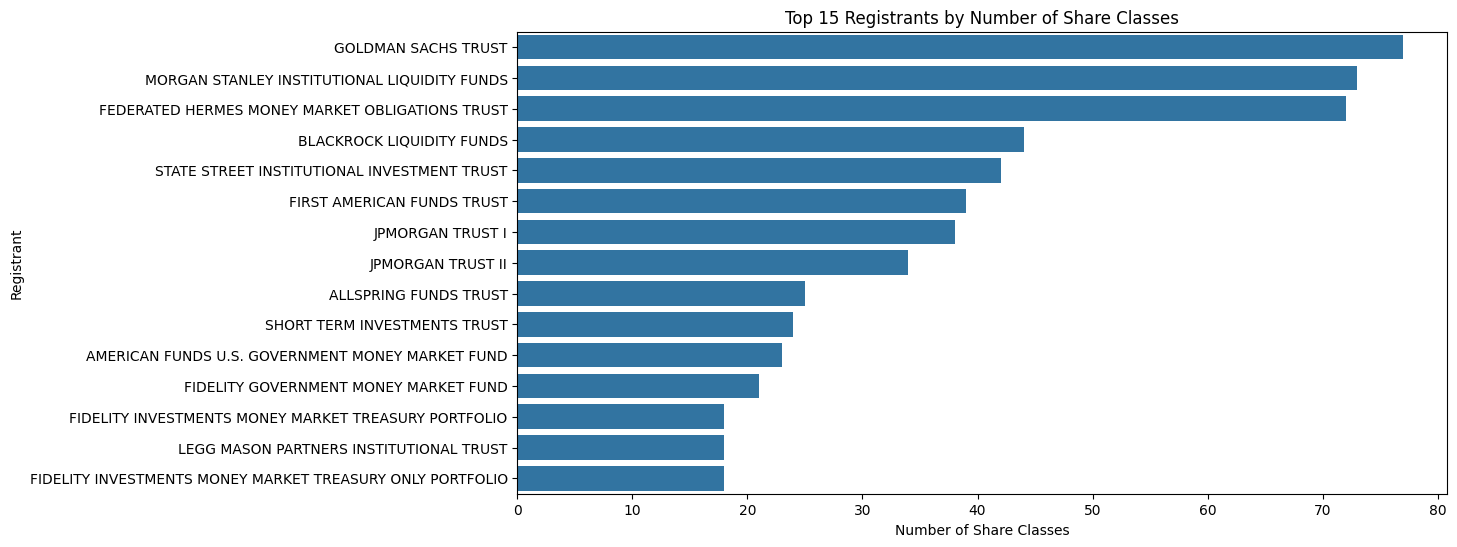

In [ ]:
top_registrants = (
    df["registrant"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(
    y=top_registrants.index,
    x=top_registrants.values,
)

plt.title("Top 15 Registrants by Number of Share Classes")
plt.xlabel("Number of Share Classes")
plt.ylabel("Registrant")

plt.show()

In [ ]:
## Distribution of Fund Categories

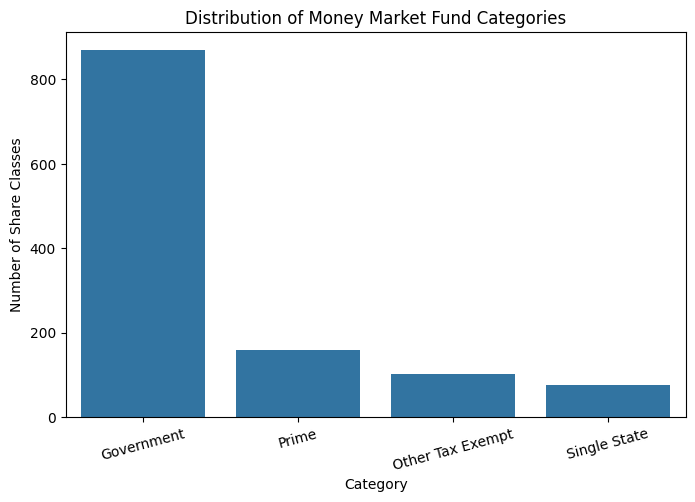

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="series_category",
    order=df["series_category"].value_counts().index
)

plt.title("Distribution of Money Market Fund Categories")
plt.xlabel("Category")
plt.ylabel("Number of Share Classes")

plt.xticks(rotation=15)

plt.show()

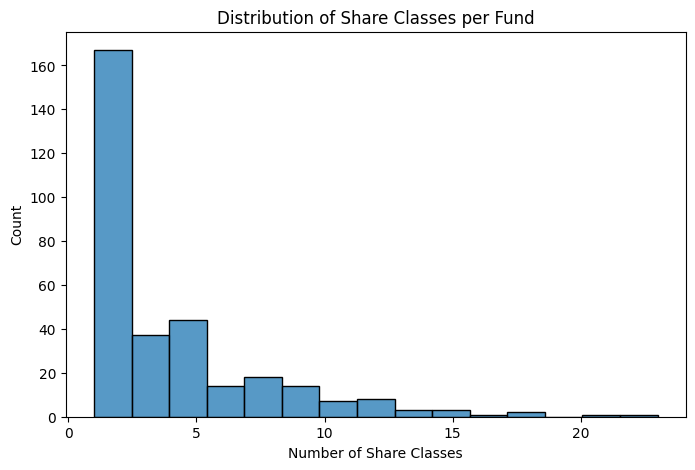

In [ ]:
share_classes = (
    df.groupby("series_id")
      .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    share_classes,
    bins=15
)

plt.title("Distribution of Share Classes per Fund")

plt.xlabel("Number of Share Classes")

plt.show()

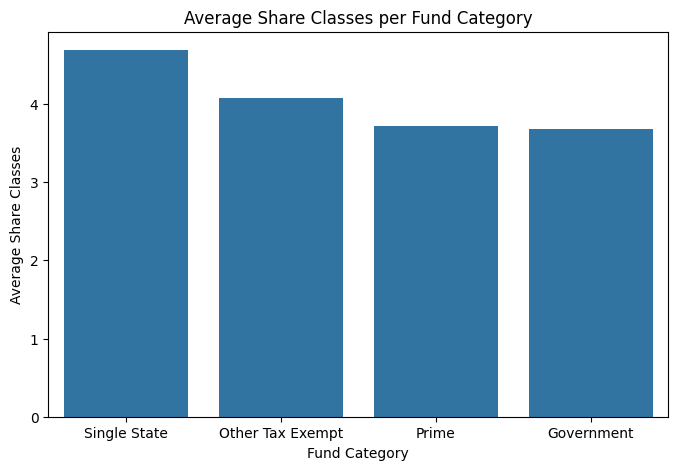

In [ ]:
share_counts = (
    df.groupby(["series_category","series_id"])
      .size()
      .reset_index(name="share_class_count")
)

avg = (
    share_counts
    .groupby("series_category")["share_class_count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg.index,
    y=avg.values
)

plt.ylabel("Average Share Classes")

plt.xlabel("Fund Category")

plt.title("Average Share Classes per Fund Category")

plt.show()

In [ ]:
## Heatmap

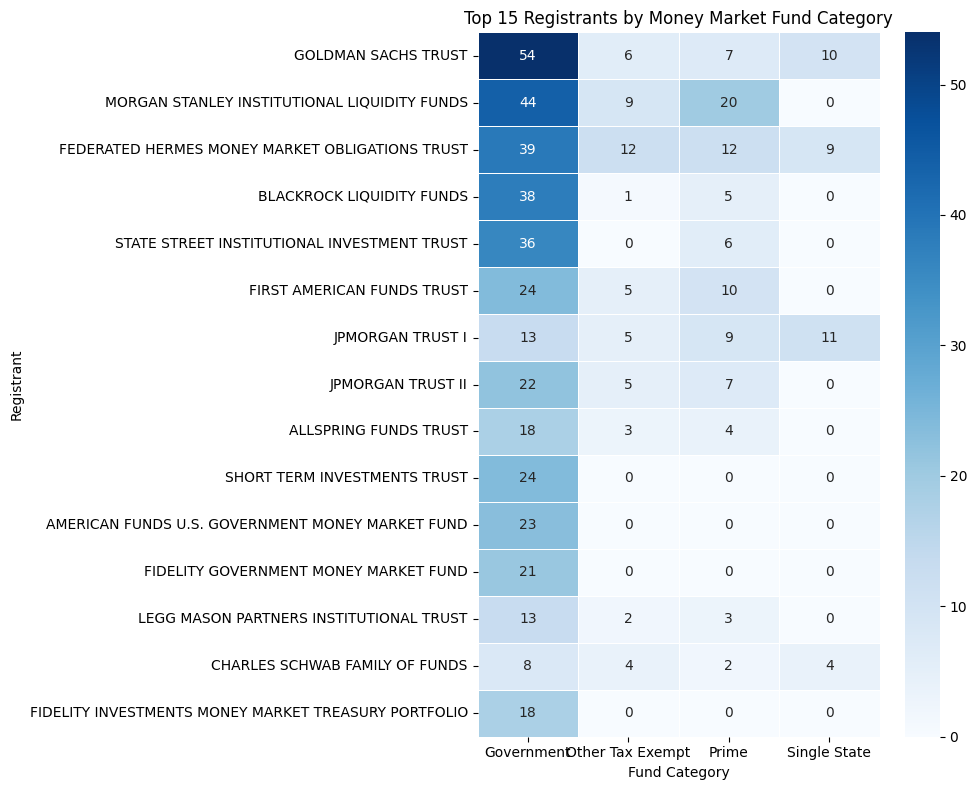

In [ ]:
# Create a table of share class counts by registrant and fund category
registrant_category = pd.crosstab(
    df["registrant"],
    df["series_category"]
)

# Keep only the top 15 registrants by total number of share classes
top_15 = (
    registrant_category
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

heatmap_data = registrant_category.loc[top_15]

# Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Top 15 Registrants by Money Market Fund Category")
plt.xlabel("Fund Category")
plt.ylabel("Registrant")

plt.tight_layout()
plt.show()

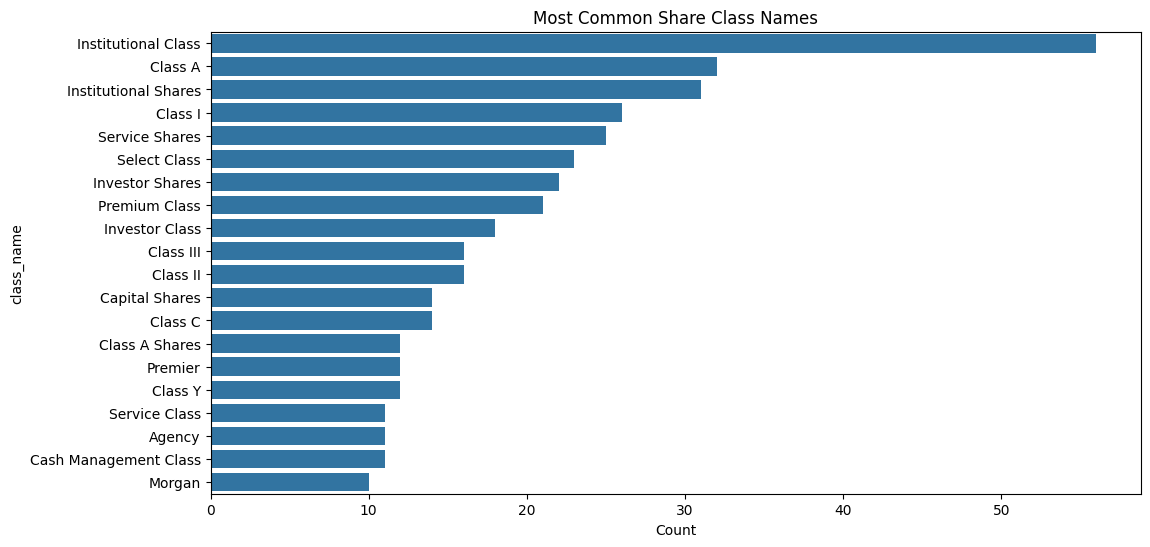

In [ ]:
top_classes = (
    df["class_name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    y=top_classes.index,
    x=top_classes.values
)

plt.title("Most Common Share Class Names")

plt.xlabel("Count")

plt.show()